## SETUP


In [1]:
import matplotlib.pyplot as plt
import pandas as pd


def load_data(p): return pd.read_csv(p)
def mi_stats(df):
    vals=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    return vals.mean(),vals.median(),vals.std(),len(vals)
def raw_stats(df,col):
    vals=pd.to_numeric(df[col],errors='coerce').dropna()
    return pd.Series({'mean':f'{vals.mean():.2f}','median':f'{vals.median():.2f}',
                      'std':f'{vals.std():.2f}','min':f'{vals.min():.2f}',
                      'max':f'{vals.max():.2f}','n':len(vals)})


### Load result to data frame


In [2]:
single=load_data('../single/result.csv'); multi=load_data('../multi/result.csv')


# RAW MI -- All Entries


#### Overall MI Δ


Single (n=279):  ΔMI = -1.63 +/- 8.83  (median: -1.87)
Multi (n=279):  ΔMI = -1.54 +/- 6.77  (median: +0.00)


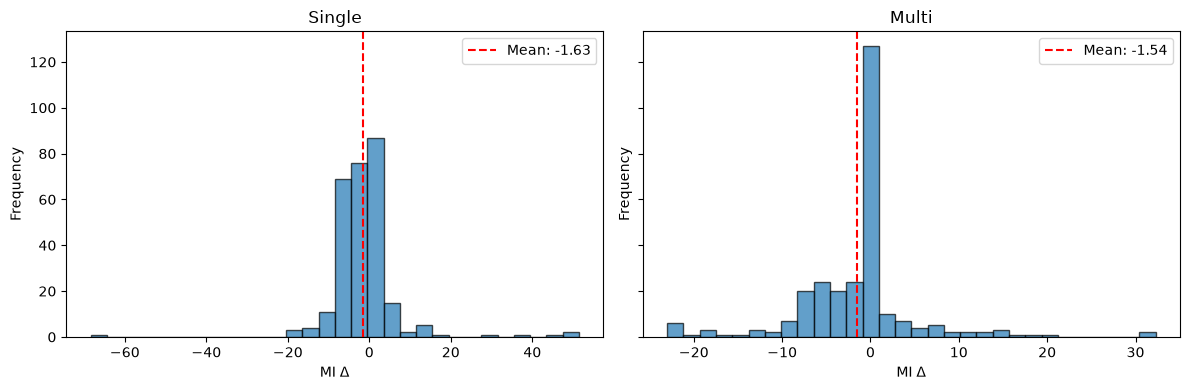

Breakdown by exit_status:
  Multi ABORT_STRATEGY (n=77):  ΔMI = +0.00 +/- 0.00
  Multi SUCCESS (n=202):  ΔMI = -2.13 +/- 7.89
  Single NO_CHANGE (n=7):  ΔMI = +0.00 +/- 0.00
  Single SUCCESS (n=272):  ΔMI = -1.67 +/- 8.94


In [3]:
for label,df in [('Single',single),('Multi',multi)]:
    m,med,s,n=mi_stats(df)
    print(f'{label} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,(label,df) in zip(axes,[('Single',single),('Multi',multi)]):
    vals=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    ax.hist(vals,bins=30,edgecolor='black',alpha=0.7)
    ax.axvline(vals.mean(),color='red',linestyle='--',label=f'Mean: {vals.mean():+.2f}')
    ax.set_title(label); ax.set_xlabel('MI Δ'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.savefig('../charts/mi/mi_overall_raw.png', dpi=100, bbox_inches='tight')
plt.show()
print('Breakdown by exit_status:')
for es,grp in pd.concat([single.assign(source='Single'),multi.assign(source='Multi')]).groupby(['source','exit_status']):
    m,med,s,n=mi_stats(grp)
    print(f'  {es[0]} {es[1]} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}')


#### Raw MI Values (Original vs Refactored)


=== Single ===
       original_mi refactored_mi mi_delta
mean         53.41         51.78    -1.63
median       54.13         52.00    -1.87
std          16.64         15.82     8.83
min           0.00          0.00   -68.39
max         107.23        107.23    51.46
n              279           279      279

=== Multi ===
       original_mi refactored_mi mi_delta
mean         53.41         51.87    -1.54
median       54.13         51.29     0.00
std          16.64         17.33     6.77
min           0.00          0.00   -23.01
max         107.23        107.23    32.27
n              279           279      279



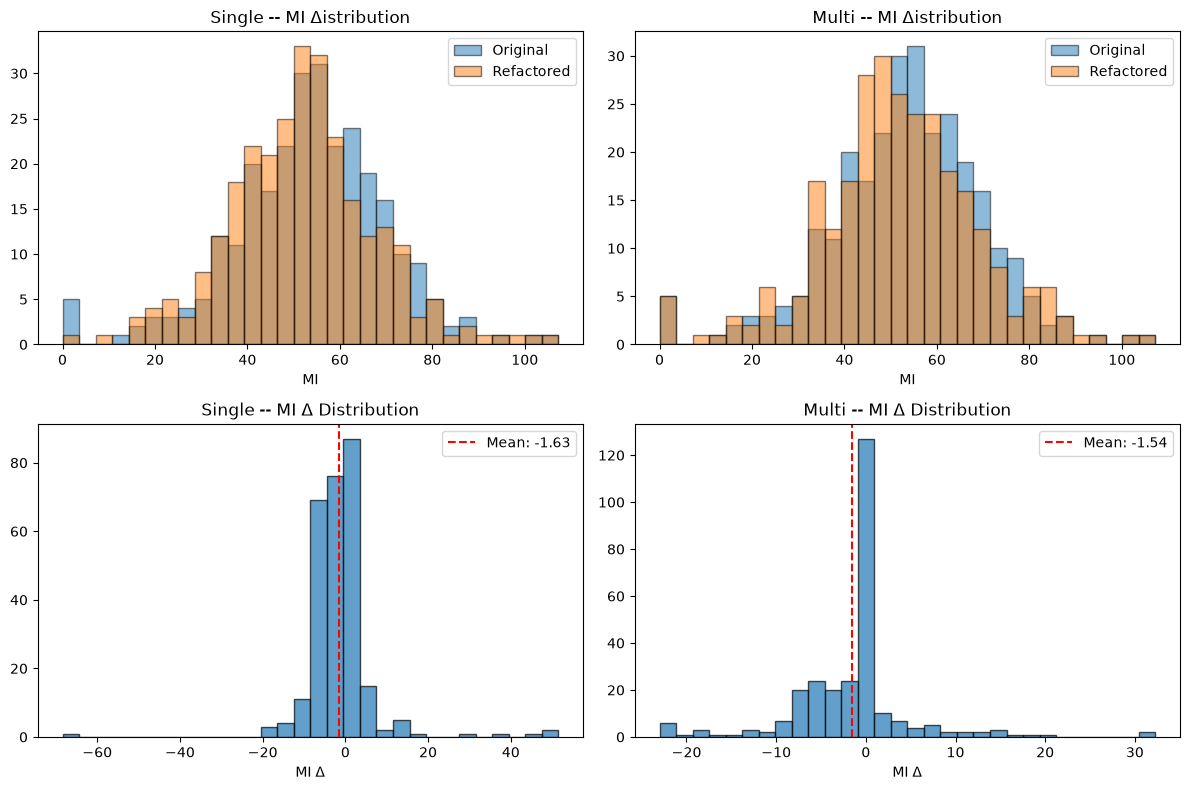

In [4]:
cols=['original_mi','refactored_mi','mi_delta']
for label,df in [('Single',single),('Multi',multi)]:
    print(f'=== {label} ===')
    print(pd.DataFrame({c:raw_stats(df,c) for c in cols})); print()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for i,(label,df) in enumerate([('Single',single),('Multi',multi)]):
    orig=pd.to_numeric(df['original_mi'],errors='coerce').dropna()
    refa=pd.to_numeric(df['refactored_mi'],errors='coerce').dropna()
    axes[0][i].hist(orig,bins=30,alpha=0.5,label='Original',edgecolor='black')
    axes[0][i].hist(refa,bins=30,alpha=0.5,label='Refactored',edgecolor='black')
    axes[0][i].set_title(f'{label} -- MI Δistribution'); axes[0][i].set_xlabel('MI'); axes[0][i].legend()
    delta=pd.to_numeric(df['mi_delta'],errors='coerce').dropna()
    axes[1][i].hist(delta,bins=30,edgecolor='black',alpha=0.7)
    axes[1][i].axvline(delta.mean(),color='red',linestyle='--',label=f'Mean: {delta.mean():+.2f}')
    axes[1][i].set_title(f'{label} -- MI Δ Distribution'); axes[1][i].set_xlabel('MI Δ'); axes[1][i].legend()
plt.tight_layout(); plt.savefig('../charts/mi/mi_distribution_raw.png', dpi=100, bbox_inches='tight')
plt.show()


#### Per-Intent MI Δ


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       1.81   0.14
DECOMPOSE_CONDITIONAL        -3.65  -3.47
EXTRACT_CONSTANT              4.79  -0.55
EXTRACT_METHOD               -5.42  -8.04
EXTRACT_VARIABLE             -1.30  -0.39
FLATTEN_CONDITIONAL          -0.49   0.88
INLINE_METHOD                -0.99  -1.24
INLINE_VARIABLE              -1.54   8.37
REMOVE_CONTROL_FLAG           4.44   2.69
RENAME_SYMBOL                 0.04  -1.22
REPLACE_LOOP_WITH_PIPELINE   -1.05   2.87
SPLIT_LOOP                   -4.41  -2.32


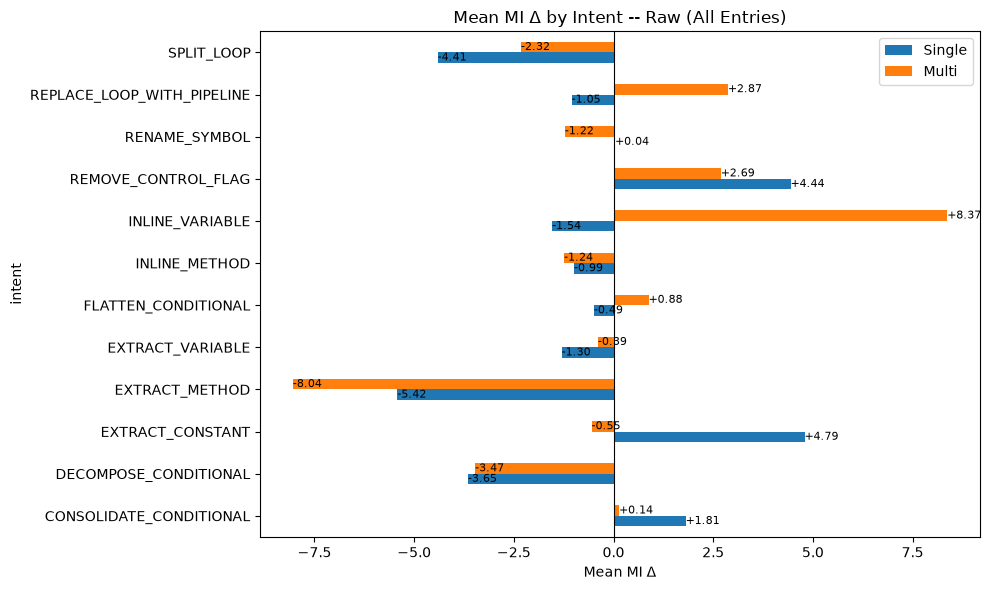

In [5]:
def intent_mi(df):
    return df.groupby('intent')['mi_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
mi_intent=pd.DataFrame({'Single':intent_mi(single),'Multi':intent_mi(multi)})
print(mi_intent)
ax=mi_intent.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Intent -- Raw (All Entries)')
for p in ax.patches:
    ax.annotate(f'{p.get_width():+.2f}',(p.get_width(),p.get_y()+p.get_height()/2),ha='left',va='center',fontsize=8)
ax.set_xlabel('Mean MI Δ'); plt.tight_layout(); plt.savefig('../charts/mi/mi_per_intent_raw.png', dpi=100, bbox_inches='tight')
plt.show()


#### MI Δ by Difficulty


            Single  Multi
difficulty               
Easy         -1.13  -1.32
Hard         -1.22  -1.88
Medium       -1.99  -1.52


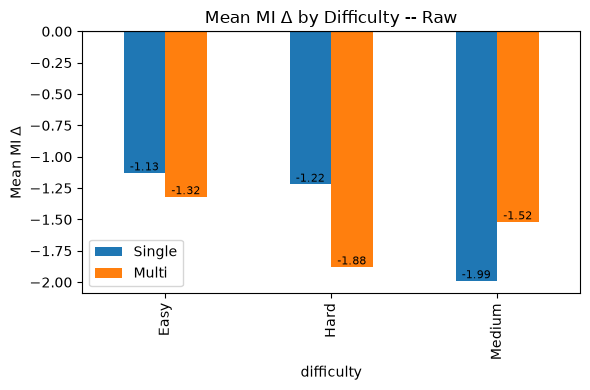

In [6]:
def diff_mi(df):
    return df.groupby('difficulty')['mi_delta'].apply(lambda x:pd.to_numeric(x,errors='coerce').mean()).round(2)
mi_diff=pd.DataFrame({'Single':diff_mi(single),'Multi':diff_mi(multi)})
print(mi_diff)
ax=mi_diff.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Difficulty -- Raw'); ax.set_ylabel('Mean MI Δ')
for p in ax.patches:
    ax.annotate(f'{p.get_height():+.2f}',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.savefig('../charts/mi/mi_diff_raw.png', dpi=100, bbox_inches='tight')
plt.show()


# MI -- SUCCESS Exit Only


#### Overall MI Δ (SUCCESS Only)


Single (n=272):  ΔMI = -1.67 +/- 8.94  (median: -2.04)
Multi (n=202):  ΔMI = -2.13 +/- 7.89  (median: -1.96)


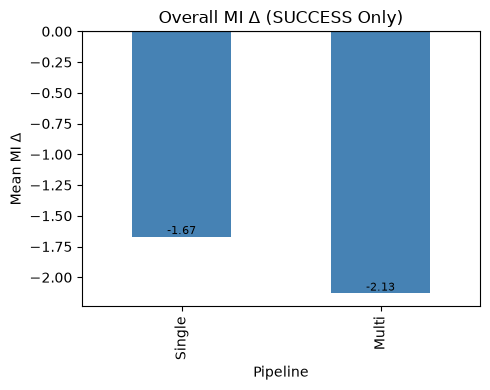

In [7]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
rows=[]
for label,df in [('Single',s_valid),('Multi',m_valid)]:
    m,med,s,n=mi_stats(df)
    print(f'{label} (n={n}):  ΔMI = {m:+.2f} +/- {s:.2f}  (median: {med:+.2f})')
    rows.append({'Pipeline':label,'ΔMI':round(m,2)})
ax = pd.DataFrame(rows).set_index('Pipeline').plot.bar(figsize=(5,4),color=['steelblue','coral'],legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():+.2f}',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.axhline(0,color='black',linewidth=0.8); plt.ylabel('Mean MI Δ'); plt.title('Overall MI Δ (SUCCESS Only)')
plt.tight_layout(); plt.savefig('../charts/mi/mi_overall_success.png', dpi=100, bbox_inches='tight')
plt.show()


#### Per-Intent MI Δ (SUCCESS Only)


                            Single  Multi
intent                                   
CONSOLIDATE_CONDITIONAL       2.02   1.02
DECOMPOSE_CONDITIONAL        -3.65  -3.62
EXTRACT_CONSTANT              5.32  -0.78
EXTRACT_METHOD               -5.42  -8.04
EXTRACT_VARIABLE             -1.56  -0.78
FLATTEN_CONDITIONAL          -0.49   2.19
INLINE_METHOD                -0.99  -2.17
INLINE_VARIABLE              -1.76   8.93
REMOVE_CONTROL_FLAG           4.44   3.08
RENAME_SYMBOL                 0.04  -1.43
REPLACE_LOOP_WITH_PIPELINE   -1.05   3.06
SPLIT_LOOP                   -4.41  -6.45


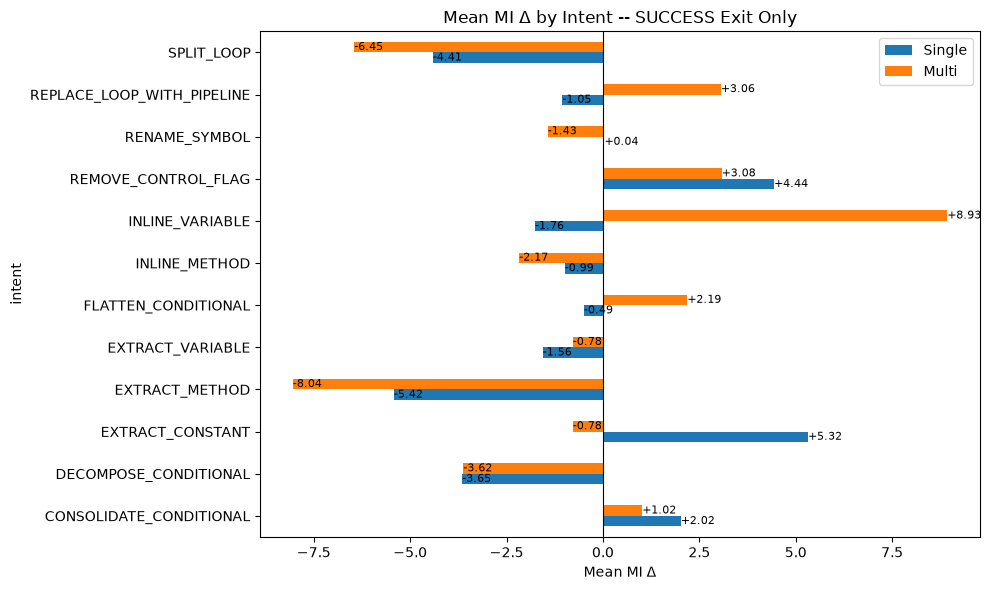

In [8]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
mi_succ=pd.DataFrame({'Single':intent_mi(s_valid),'Multi':intent_mi(m_valid)})
print(mi_succ)
ax=mi_succ.plot.barh(figsize=(10,6))
ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Intent -- SUCCESS Exit Only')
for p in ax.patches:
    ax.annotate(f'{p.get_width():+.2f}',(p.get_width(),p.get_y()+p.get_height()/2),ha='left',va='center',fontsize=8)
ax.set_xlabel('Mean MI Δ'); plt.tight_layout(); plt.savefig('../charts/mi/mi_per_intent_success.png', dpi=100, bbox_inches='tight')
plt.show()


#### MI Δ by Difficulty (SUCCESS Only)


            Single  Multi
difficulty               
Easy         -1.16  -1.55
Hard         -1.29  -2.52
Medium       -2.02  -2.31


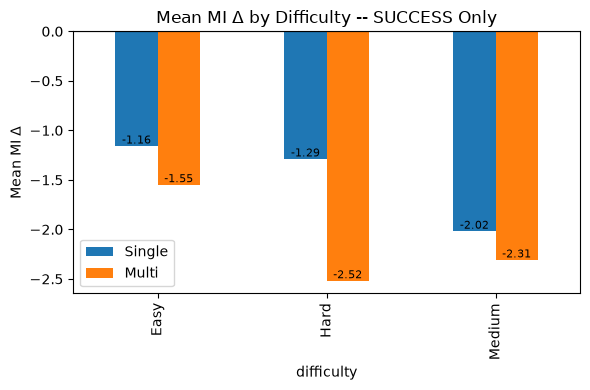

In [9]:
s_valid=single[single['exit_status']=='SUCCESS']
m_valid=multi[multi['exit_status']=='SUCCESS']
mi_diff_succ=pd.DataFrame({'Single':diff_mi(s_valid),'Multi':diff_mi(m_valid)})
print(mi_diff_succ)
ax=mi_diff_succ.plot.bar(figsize=(6,4))
ax.axhline(0,color='black',linewidth=0.8)
ax.set_title('Mean MI Δ by Difficulty -- SUCCESS Only'); ax.set_ylabel('Mean MI Δ')
for p in ax.patches:
    ax.annotate(f'{p.get_height():+.2f}',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.savefig('../charts/mi/mi_diff_success.png', dpi=100, bbox_inches='tight')
plt.show()
